# Diffusion Model — Custom Cat Dataset (64×64)

Adapted from CIFAR-10 cat diffusion. Key changes:
- Dataset: **local `cat/` folder** with PNG/JPG images
- Image shape: `(3, 64, 64)` — RGB, 64×64 pixels
- No label filtering needed: all images in the folder are cats


In [1]:
import sys
from pathlib import Path
import os

directorio_padre = str(Path.cwd().parent)

if directorio_padre not in sys.path:
    sys.path.append(directorio_padre)
    cwd = Path.cwd().resolve()
for path_entry in (cwd, cwd.parent):
    if str(path_entry) not in sys.path:
        sys.path.append(str(path_entry))

In [10]:
import sys
from pathlib import Path


import numpy as np
from functools import partial

import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

from diffusion_lib.legacy import diffusion_process as dfp

from diffusion_lib.utils.visualization import (
    plot_image_grid,
    plot_image_evolution_rgb,
    animation_images,
)



n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

device = 'cuda' 

Number of threads: 10


## 1. Load custom cat images from local `cat/` folder


In [12]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor

class CatFolderDataset(Dataset):
    def __init__(self, folder_path):
        self.transform = ToTensor()
        paths = sorted(Path(folder_path).glob('*.jpg'))
        # carga todo en memoria al inicio
        self.images = [self.transform(Image.open(p).convert('RGB')) for p in paths]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], 0


data_train = CatFolderDataset('cats')
print(f'Number of cat images: {len(data_train)}')
print(f'Image tensor shape  : {data_train[0][0].shape}')  # (3, 64, 64)

Number of cat images: 15747
Image tensor shape  : torch.Size([3, 64, 64])


## 2. Visualize a few samples

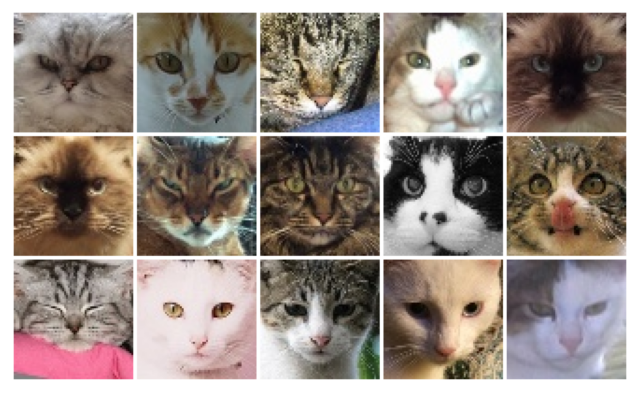

In [13]:
n_rows = 3
n_cols = 5

# Each item is (tensor_3x64x64, label) — we pass the image tensor directly
_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(8, 5),
    n_rows=n_rows,
    n_cols=n_cols,
)


## 3. Diffusion process (unchanged)

In [14]:
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    """Zero drift — Brownian motion with no deterministic component."""
    return torch.zeros_like(x_t)

def bm_diffusion_coefficient(t, sigma=sigma):
    """Exponentially growing diffusion coefficient."""
    return sigma**t

def bm_mu_t(x_0, t):
    """Mean of the forward process at time t equals the original image."""
    return x_0

def bm_sigma_t(t, sigma=sigma):
    """Standard deviation of the forward process at time t."""
    return torch.sqrt(0.5 * (sigma**(2 * t) - 1.0) / np.log(sigma))

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=bm_drift_coefficient,
    diffusion_coefficient=bm_diffusion_coefficient,
    mu_t=bm_mu_t,
    sigma_t=bm_sigma_t,
)

## 4. Score model

> **Note:** `ScoreNet` must accept 3-channel 32×32 inputs.  
> If your original `ScoreNet` was hard-coded for `(1, 28, 28)`, update its first conv layer accordingly (e.g. `in_channels=3`).

In [15]:
from cat_AI_v2.score_model import ScoreNet

# CHANGE 4: If ScoreNet accepts an `in_channels` or `image_size` argument, pass it here.
# Example (adapt to your ScoreNet signature):
#   ScoreNet(marginal_prob_std=..., in_channels=3)
score_model = torch.nn.DataParallel(
    ScoreNet(
        marginal_prob_std=partial(bm_sigma_t, sigma=sigma)
    )
)
score_model = score_model.to(device)

In [16]:
import importlib
import cat_AI_v2.score_model as sm
importlib.reload(sm)

from functools import partial

score_model = torch.nn.DataParallel(
    sm.ScoreNet(
        marginal_prob_std=partial(bm_sigma_t, sigma=sigma)
    )
)
score_model = score_model.to(device)

In [17]:
import inspect
print(inspect.getsource(score_model.module.forward))

    def forward(self, x, t):
        embed = self.act(self.embed(t))

        # Encoder
        h1 = self.act(self.gnorm1(self.conv1(x)  + self.dense1(embed)))  # (B, 32, 32, 32)
        h2 = self.act(self.gnorm2(self.conv2(h1) + self.dense2(embed)))  # (B, 64, 16, 16)
        h3 = self.act(self.gnorm3(self.conv3(h2) + self.dense3(embed)))  # (B, 128, 8, 8)
        h4 = self.act(self.gnorm4(self.conv4(h3) + self.dense4(embed)))  # (B, 256, 4, 4)

        # Decoder con skip connections
        h = self.act(self.tgnorm4(self.tconv4(h4) + self.dense5(embed)))              # (B, 128, 8, 8)
        h = self.act(self.tgnorm3(self.tconv3(torch.cat([h, h3], dim=1)) + self.dense6(embed)))  # (B, 64, 16, 16)
        h = self.act(self.tgnorm2(self.tconv2(torch.cat([h, h2], dim=1)) + self.dense7(embed)))  # (B, 32, 32, 32)
        h = self.tconv1(torch.cat([h, h1], dim=1))                                    # (B, 3, 32, 32)

        h = h / self.marginal_prob_std(t)[:, None, None, None]
        re

## 5. Training loop

In [ ]:
print("device variable:", device)
print("modelo en:", next(score_model.parameters()).device)
print("CUDA disponible:", torch.cuda.is_available())

In [20]:
from torch.optim import Adam
import tqdm

batch_size = 256

data_loader = DataLoader(
    data_train,
    batch_size=64,
    shuffle=True,
    num_workers=0,      # en Windows+notebook siempre 0
    pin_memory=True,    # sigue siendo útil para la transferencia a GPU
)

learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 2000
tqdm_epoch = tqdm.trange(n_epochs)

for epoch in tqdm_epoch:  
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader:
        x = x.to(device)
        loss = diffusion_process.loss_function(score_model, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))

torch.save(score_model.state_dict(), 'kaggle_cats_{:d}_epochs.pth'.format(n_epochs))

Average Loss: 215.662700:   0%|          | 9/2000 [02:47<10:17:19, 18.60s/it]


KeyboardInterrupt: 

## 6. Generate synthetic cat images

In [41]:
n_images = 3

checkpoint_path = 'cat64_diffusion_2000_epochs.pth'
check_point = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
score_model.load_state_dict(check_point)

score_model_cpu = score_model.module.cpu()
score_model_cpu.eval()

def backward_drift_coefficient(x_t, t, diffusion_coefficient):
    if not isinstance(t, torch.Tensor):
        t = torch.tensor([t], dtype=torch.float32)
    if t.dim() == 0 or t.shape[0] != x_t.shape[0]:
        t = t.expand(x_t.shape[0])
    score = score_model_cpu(x_t, t)
    view_shape = [x_t.shape[0]] + [1] * (x_t.dim() - 1)
    g_t = diffusion_coefficient(t).view(*view_shape)
    return -(g_t ** 2) * score

T = 1.0
t_tensor = torch.tensor([T])
sigma_max = diffusion_process.sigma_t(t_tensor).detach()
image_T = torch.randn(n_images, 3, 64, 64) * sigma_max.view(1, 1, 1, 1)

with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        drift_coefficient=partial(
            backward_drift_coefficient,
            diffusion_coefficient=bm_diffusion_coefficient,
        ),
        diffusion_coefficient=bm_diffusion_coefficient,
    )

print(synthetic_images_t.shape)

# Volver a poner el modelo en GPU para seguir entrenando
score_model = score_model.to(device)
score_model.train()

torch.Size([3, 3, 64, 64, 501])


DataParallel(
  (module): ScoreNet(
    (embed): Sequential(
      (0): GaussianRandomFourierFeatures()
      (1): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (dense1): Dense(
      (dense): Linear(in_features=256, out_features=32, bias=True)
    )
    (gnorm1): GroupNorm(4, 32, eps=1e-05, affine=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (dense2): Dense(
      (dense): Linear(in_features=256, out_features=64, bias=True)
    )
    (gnorm2): GroupNorm(32, 64, eps=1e-05, affine=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (dense3): Dense(
      (dense): Linear(in_features=256, out_features=128, bias=True)
    )
    (gnorm3): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (dens

## 7. Visualize the denoising evolution

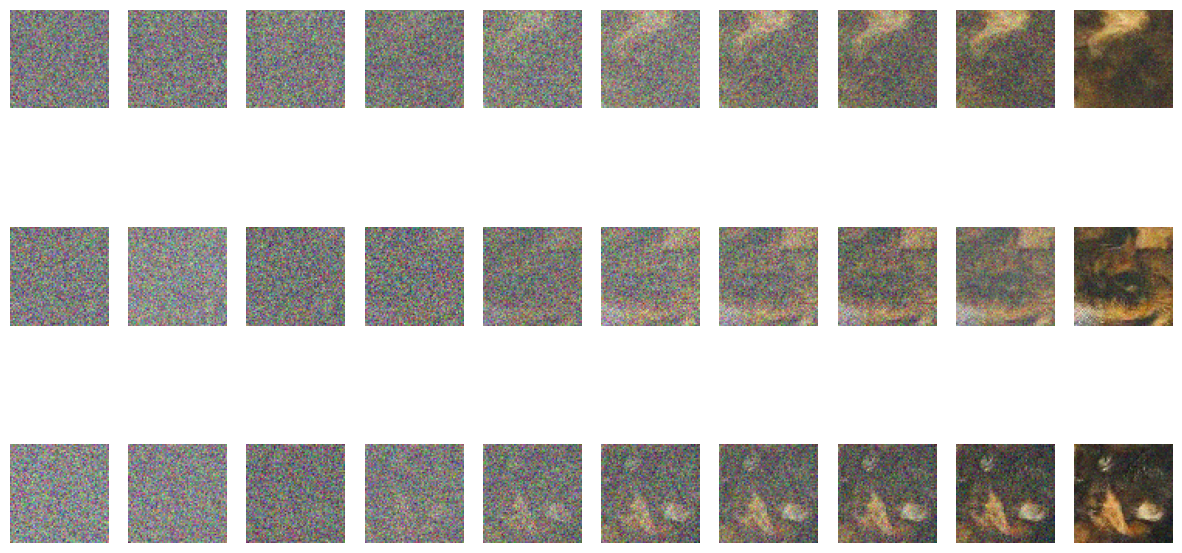

In [ ]:
_ = plot_image_evolution_rgb(
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 8),
)